In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u

import aplpy

from reproject import reproject_interp
from spectral_cube import SpectralCube
from matplotlib.colors import LogNorm

# Making an RGB image:
from astropy.visualization import make_lupton_rgb

In [2]:
# Open and plot the data for W51:

# Atlasgal:
W51_atlasgal_file = 'ATLASGAL-SPIRE/W51/W51_atlasgal.fits'

# We will use SPIRE to make an RGB image:
W51_spire500_file = 'ATLASGAL-SPIRE/W51/SpireParallel_L25_PMP500_SPG14.0.fits'
W51_spire350_file = 'ATLASGAL-SPIRE/W51/SpireParallel_L25_PMP350_SPG14.0.fits'
W51_spire250_file = 'ATLASGAL-SPIRE/W51/SpireParallel_L25_PMP250_SPG14.0.fits'

# VLA 18cm:
W51_radio_file = 'VLAdata/HYGAL_W51_oh1_niter100000_threshold100mJybeam_highres_cube.20arcsec.image.pbcor.fits'

INFO: Auto-setting vmin to -4.271e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.363e+01 [aplpy.core]


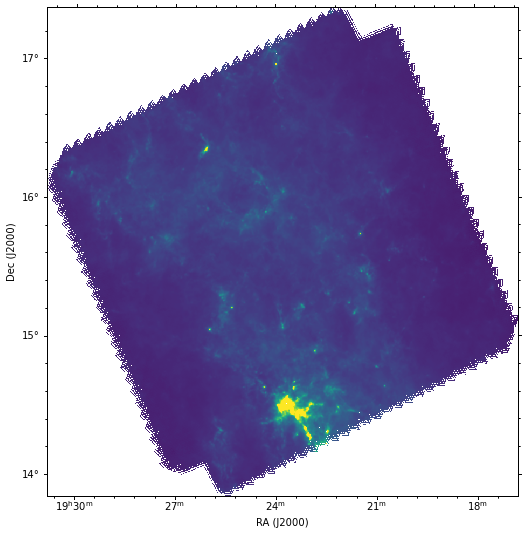

In [3]:
gc = aplpy.FITSFigure(W51_spire500_file, hdu=1)
gc.show_colorscale()

INFO: Auto-setting vmin to -3.829e-01 [aplpy.core]
INFO: Auto-setting vmax to  8.475e-01 [aplpy.core]


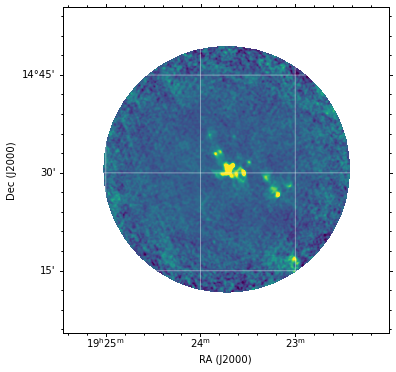

In [4]:
f = aplpy.FITSFigure(W51_radio_file, slices=[100], figsize=(6,6))
f.show_colorscale()
f.add_grid()

In [5]:
W51_radio = fits.open(W51_radio_file)
W51_radioCube = SpectralCube.read(W51_radio)
W51_radio.close()

In [6]:
print(W51_radioCube)

SpectralCube with shape=(795, 1000, 1000) and unit=Jy / beam:
 n_x:   1000  type_x: RA---SIN  unit_x: deg    range:   290.502563 deg:  291.364133 deg
 n_y:   1000  type_y: DEC--SIN  unit_y: deg    range:    14.091549 deg:   14.924057 deg
 n_s:    795  type_s: VRAD      unit_s: m / s  range:   -58800.000 m / s:  100000.000 m / s


INFO: Auto-setting vmin to -4.298e-01 [aplpy.core]
INFO: Auto-setting vmax to  1.040e+00 [aplpy.core]


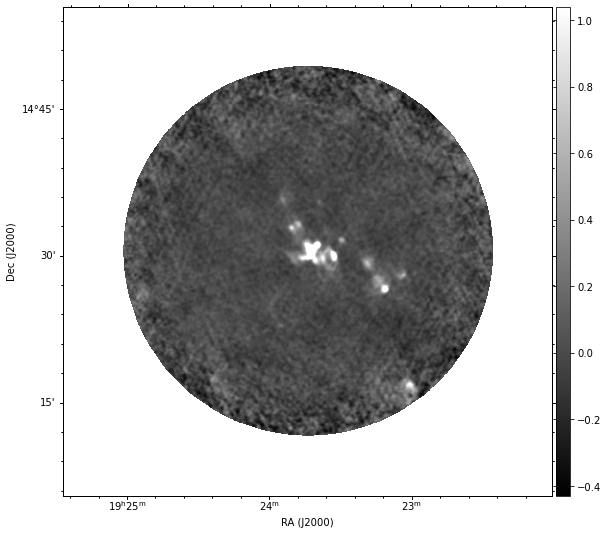

In [7]:
W51_radioCube[30,:,:].quicklook()

In [10]:
W51moment_0 = W51_radioCube.with_spectral_unit(u.km/u.s).moment(order=0)

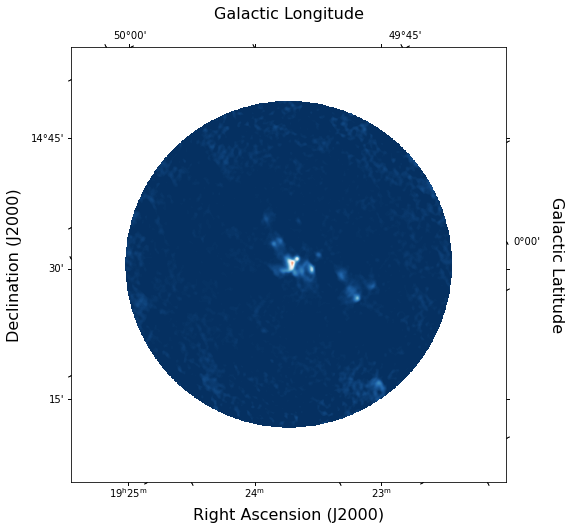

In [12]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection=W51moment_0.wcs)

im = ax.imshow(W51moment_0.hdu.data, cmap='RdBu_r', vmin=0, vmax=1000)

# Axis labels:
ax.coords[0].set_axislabel('Right Ascension (J2000)', fontsize=16)
ax.coords[1].set_axislabel('Declination (J2000)', fontsize=16)

# Overlay set of Gal/Dec Axes
overlay = ax.get_coords_overlay('galactic')
overlay[0].set_axislabel('Galactic Longitude', fontsize=16)
overlay[1].set_axislabel('Galactic Latitude', fontsize=16)

In [13]:
# Getting the Hershel information:
ir_image = fits.open(W51_spire500_file)

In [14]:
spire_header = ir_image[1].header
spire_wcs = WCS(ir_image[1])
spire_image = ir_image[1]
print(spire_wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 291.1197231356044  15.67476097216787  
CRPIX : 395.0  470.0  
NAXIS : 874  908


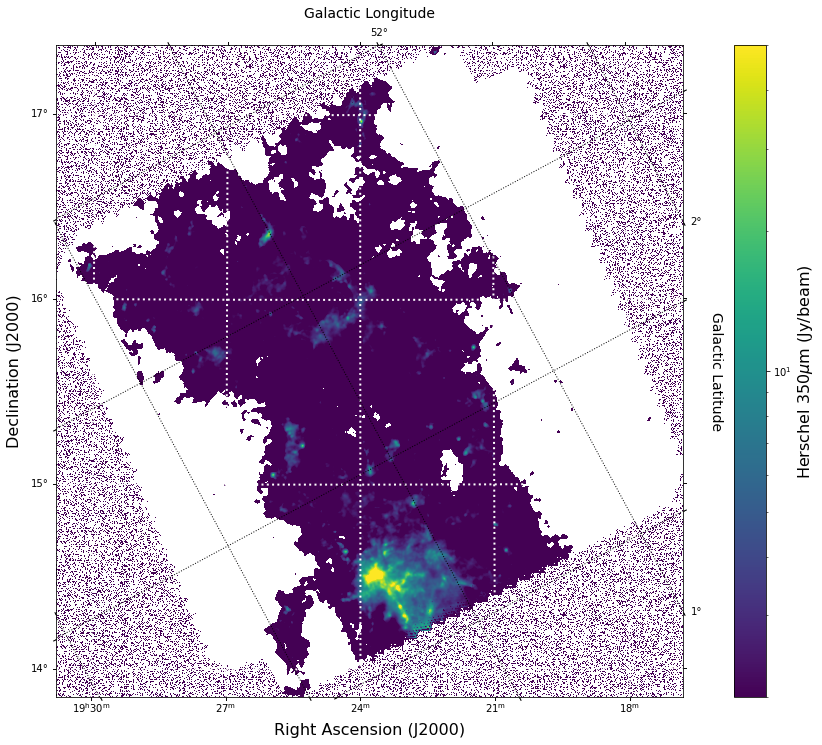

In [15]:
# Set nans to zero:
radio_nan_locs = np.isnan(spire_image.data)
spire_data_nonans = spire_image.data
spire_data_nonans[radio_nan_locs] = 0

# Initiate a figure with the Spire WCS:
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection=spire_wcs)

# Display the image data:
im = ax.imshow(spire_data_nonans, cmap='viridis', norm=LogNorm(vmin=2, vmax=50))

# Add axes labels:
ax.set_xlabel("Right Ascension (J2000)", fontsize=16)
ax.set_ylabel("Declination (J2000)", fontsize=16)
ax.grid(color='white', ls='dotted', lw=2)

# Add colorbor:
cbar = plt.colorbar(im, pad=.05)
cbar.set_label(''.join(['Herschel 350'r'$\mu$m ', '(', spire_header['BUNIT'], ')']), size=16)

# Overlay a set of Galactic Coordinates:
overlay = ax.get_coords_overlay('galactic') 
overlay.grid(color='black', ls='dotted', lw=1)
overlay[0].set_axislabel('Galactic Longitude', fontsize=14)
overlay[1].set_axislabel('Galactic Latitude', fontsize=14)

(-0.5, 907.5)

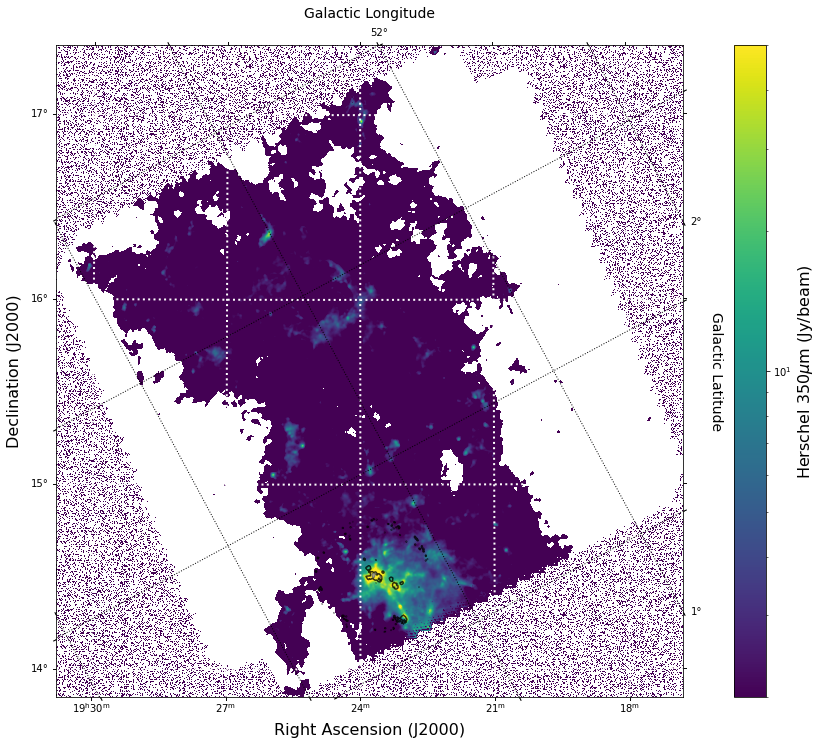

In [23]:
# Set nans to zero:
radio_nan_locs = np.isnan(spire_image.data)
spire_data_nonans = spire_image.data
spire_data_nonans[radio_nan_locs] = 0

# Initiate a figure with the Spire WCS:
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection=spire_wcs)

# Display the image data:
im = ax.imshow(spire_data_nonans, cmap='viridis', norm=LogNorm(vmin=2, vmax=50))

# Add axes labels:
ax.set_xlabel("Right Ascension (J2000)", fontsize=16)
ax.set_ylabel("Declination (J2000)", fontsize=16)
ax.grid(color='white', ls='dotted', lw=2)

# Extract x and y coordinate limits
x_lim = ax.get_xlim()
y_lim = ax.get_ylim()

# Add colorbor:
cbar = plt.colorbar(im, pad=.05)
cbar.set_label(''.join(['Herschel 350'r'$\mu$m ', '(', spire_header['BUNIT'], ')']), size=16)

# Overlay a set of Galactic Coordinates:
overlay = ax.get_coords_overlay('galactic') 
overlay.grid(color='black', ls='dotted', lw=1)
overlay[0].set_axislabel('Galactic Longitude', fontsize=14)
overlay[1].set_axislabel('Galactic Latitude', fontsize=14)

# Plot the contours of the VLA moment 0 map:
radio_transform = ax.get_transform(W51moment_0.wcs) # Extract the WCS information from the VLA:

levels = np.linspace(35, 1000, 5)
ax.contour(W51moment_0.hdu.data, cmap='Greys_r', alpha=0.8, levels=levels, transform=radio_transform)

# Apply original image x and y coordinate limits
ax.set_xlim(x_lim)
ax.set_ylim(y_lim)

In [ ]:
#https://docs.astropy.org/en/stable/nddata/utils.html for 2D cutouts